In [ ]:
print("Developed by \u092A\u093F\u092F\u0942\u0937 \u0930\u093E\u091C and Checked by \u0935\u0948\u0936\u093E\u0932\u0940 \u0907\u0902\u0917\u0932\u0947")

Developed by पियूष राज and Checked by वैशाली इंगले


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import random
import numpy as np
from keras import layers, models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with np.load('/content/drive/MyDrive/Files_OA/mnist.npz', allow_pickle=True) as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test, y_test = f['x_test'], f['y_test']

In [ ]:
print(f"The length of the dataset is : {len(x_train)}")

The length of the dataset is : 60000


In [ ]:
print(f"The shape of the training dataset is {x_train.shape}")

The shape of the training dataset is (60000, 28, 28)


In [ ]:
print(f"The shape of the testing dataset is {x_test.shape}")

The shape of the testing dataset is (10000, 28, 28)


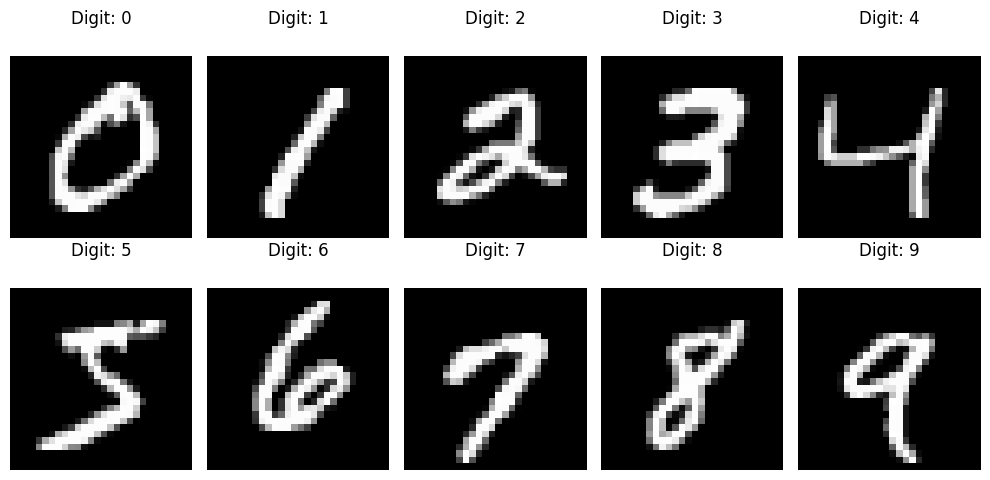

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find one index for each digit (0-9) in the training data
digit_indices = [np.where(y_train == i)[0][0] for i in range(10)]

# Display one image for each digit
plt.figure(figsize=(10, 5))
for i, idx in enumerate(digit_indices):
    plt.subplot(2, 5, i + 1)
    plt.matshow(x_train[idx], cmap='gray', fignum=0)
    plt.title(f"Digit: {y_train[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
max_pixel_value = x_train.max()
x_train = x_train.astype("float32") / max_pixel_value
x_test = x_test.astype("float32") / max_pixel_value

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='tanh'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
# Display the model architecture, showing each layer, output shape, and number of parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
history = model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7316 - loss: 0.9785 - val_accuracy: 0.9215 - val_loss: 0.2742
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9248 - loss: 0.2672 - val_accuracy: 0.9403 - val_loss: 0.2046
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9418 - loss: 0.1976 - val_accuracy: 0.9512 - val_loss: 0.1643
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9540 - loss: 0.1588 - val_accuracy: 0.9591 - val_loss: 0.1373
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9610 - loss: 0.1367 - val_accuracy: 0.9622 - val_loss: 0.1279
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9677 - loss: 0.1116 - val_accuracy: 0.9641 - val_loss: 0.1164
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9711 - loss: 0.0979 - val_accuracy: 0.9686 - val_loss: 0.1042
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9750 - loss: 0.0856 - 

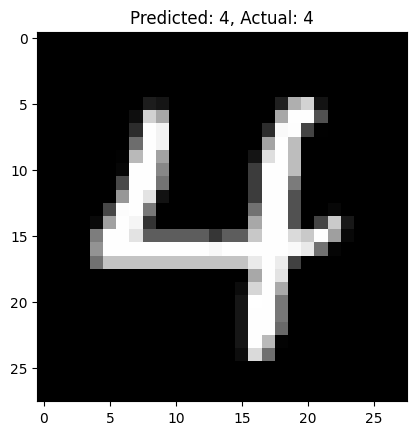

In [ ]:
n = random.randint(0, len(x_test)-1)
predicted_values = model.predict(x_test[n:n+1], verbose=0)
predicted_class = np.argmax(predicted_values[0])

plt.imshow(x_test[n], cmap='gray')
plt.title(f"Predicted: {predicted_class}, Actual: {y_test[n]}")
plt.show()

In [ ]:
# List all recorded metrics from training
list(history.history.keys())

['accuracy', 'loss', 'val_accuracy', 'val_loss']

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss = {test_loss:.3f}")
print(f"Test Accuracy = {test_acc*100:.2f}%")

Test Loss = 0.066
Test Accuracy = 97.83%


In [ ]:
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Training Loss = {train_loss:.3f}")
print(f"Training Accuracy = {train_acc*100:.2f}%")

Training Loss = 0.018
Training Accuracy = 99.71%


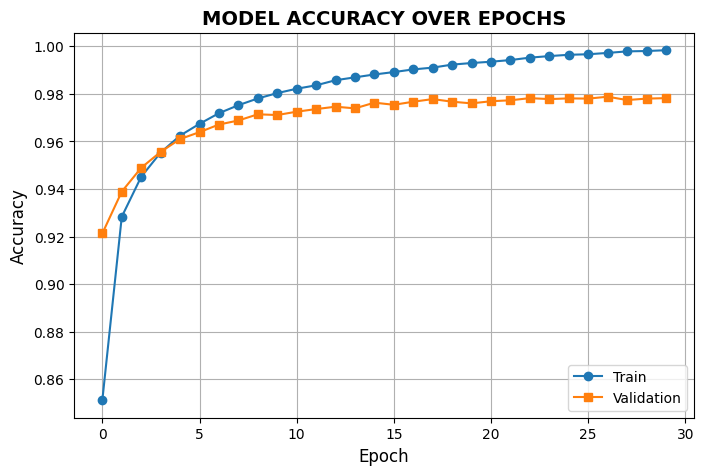

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='s')
plt.title('MODEL ACCURACY OVER EPOCHS', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)
plt.show()

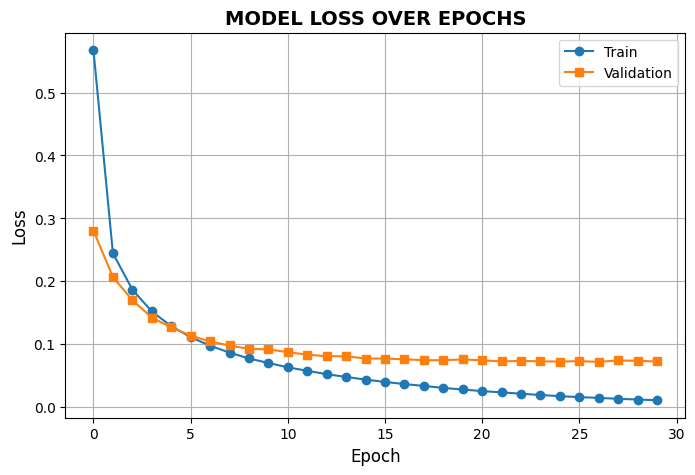

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='s')
plt.title('MODEL LOSS OVER EPOCHS', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.show()